# Stimare la velocità di rotazione della Via Lattea e il moto proprio del Sole

Ipotesi del modello di rotazione:
* Le stelle si muovono su orbite circolari
* La velocità di rotazione tangenziale $V_{rot}$ costante e indipendente dal raggio
* Si definisce Local Standard of Rest (LSR) un sistema di riferimento cartesiano con assi U, V, W che si muove con velocità $V_{rot}$. L'asse U è orientato verso il centro galattico, l'asse V nella direzione di rotazione, l'asse W perpendicolare agli altri due
* La velocità del Sole rispetto al LSR è data dalle componenti $U_{\odot}$, $V_{\odot}$, $W_{\odot}$
* Le coordinate galattiche sono un sistema di coordinate centrate nel Sole in cui la coordinata azimuth è della l, mentre quella polare è detta b. Una stella è individuata dalla terna (d, l, b).
* Il Sole è assunto sul piano galattico a distanza dal centro galattico di  $ R_{\odot} = 8200 pc $

Grazie al satellite Gaia, è possibile conoscere per ogni stella le coordinate galattiche delle stelle e i moti propri, oltre che alla distanza calcolata tramite parallasse. 

Detto $\pi$ la parallasse misurata in mas, allora la distanza della stella, in parsec, si misura come:

$ d = \frac{1000}{\pi}$

Il moto proprio è definito come la velocità della stella rispetto a quella del Sole, ovvero $\Delta{\vec{V}} = \vec {V}_{stella} - \vec{V}_{\odot}$.

Si considerano i moti propri lungo la linea di vista (velocità radiale) e nel piano del cielo, ovvero lungo le direzioni l e b.

Posti i versori...
* $\hat{n} = \left( cos(l)cos(b) , sin(l)cos(b) , sin(b) \right)$
* $\hat{e_l} = (-sin(l), cos(l), 0)$ 
* $\hat{e_b} = (-cos(l)sin(b), -sin(l)sin(b), cos(b))$

... i moti propri possono essere calcolati come:

* $V_{rad}^{obs} = \Delta \vec{V} \cdot \hat{n}$ 
* $V_{l}^{obs} = \Delta \vec{V} \cdot \hat{e_l}$ 
* $V_{b}^{obs} = \Delta \vec{V} \cdot \hat{e_b}$

Con considerazioni trigonetriche si derivano:
* $V_{star} = \left( V_{rot} \frac{d_{\parallel}}{R_{star}^{\parallel}} sin(l), V_{rot}  \frac{R_{\odot}^2 + {R_{star}^{\parallel 2 } } - d_{\parallel}^2 }{2 R_{\odot} R_{star}^{\parallel}}, 0 \right)$ 

* $V_{\odot} = \left(U_{\odot}, V_{\odot}, W_{\odot} \right)$

* $\Delta{\vec{V}} =  \left( V_{rot} \frac{d_{\parallel}}{R_{star}^{\parallel}} sin(l) - U_{\odot}, V_{rot}  \frac{R_{\odot}^2 + {R_{star}^{\parallel 2 } } - d_{\parallel}^2 }{2 R_{\odot} R_{star}^{\parallel}} - V_{\odot}, W_{\odot} \right)$

Segue che, proiettando lungo i versori...

* $V_{rad}^{obs} = V_{rot} \left[ \frac{R_{\odot}}{R_{star}^{\parallel}} -1 \right]sin(l)cos(b) - U_{\odot} cos(l) cos(b) - V_{\odot} sin(l) cos(b) - W_{\odot} sin(b) $

* $V_{l}^{obs} = V_{rot} \left[ \frac{ \left( R_{\odot} - R_{star}^{\parallel} \right) cos(l) -  d_{\parallel}} {R_{star}^{\parallel}} \right] + U_{\odot} sin(l) - V_{\odot} cos(l) $

* $V_{b}^{obs} = - V_{rot} \left[ \frac{R_{\odot}}{R_{star}^{\parallel}} -1 \right] sin(l) sin(b) + U_{\odot} cos(l) sin(b) + V_{\odot} sin(l) sin(b) - W_{\odot} cos(b) $

dove: 
* $ d_{\parallel} = d \cdot cos(b)$ 
* $R_{star}^{\parallel} = \sqrt{ R_{\odot}^2 + d_{\parallel}^2 - 2 d_{\parallel}  R_{\odot}  cos(l)}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
from scipy.optimize import least_squares
from astropy.table import Table

In [2]:
# Reading data from Gaia DR3 catalog
gaia = Table.read('gaia2.vot')

In [6]:
print(gaia.colnames)
print(gaia["pmra"])

['ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity', 'radial_velocity_error', 'l', 'b']
        pmra       
      mas / yr     
-------------------
 2.2124971986328235
 0.7505705496748409
  4.052907205945745
 10.739378115029954
-0.6534654590957305
  20.88869078685992
 0.1925041737114653
 3.1277215895125714
 -3.933826925317574
                ...
-2.2931524202408937
-1.1583199389838992
 1.8486380122642054
-0.6698164291169234
  9.840561580521449
 -4.114538181023233
 -4.218686360494658
   3.94873771187507
 -5.500672665421097
 -5.713805301357989
Length = 349153 rows


In [7]:
# Creating a mask to select only stars with good parallax measurements and radial velocity

# Position (l, b)
l = gaia['l']
b = gaia['b']

# Parallax and its error
parallax = gaia['parallax']
parallax_err = gaia['parallax_error']

# Radial velocity and its error
rv = gaia['radial_velocity']
rv_err = gaia['radial_velocity_error']

# Proper Motion in RA and Dec
pmra = gaia['pmra']
pmdec = gaia['pmdec']

# Creating a mask to select only stars CLOSE TO GALACTIC PLANE with good parallax measurements
mask = (
    (np.abs(b) < 5) &
    (parallax > 0) &
    (parallax_err / parallax < 0.2) &
    (~np.isnan(rv))
)

# Applying the mask to the data
data = gaia[mask]

# Creating a new column for distance in parsecs
distance = 1000 / data['parallax'] # parsec
data['distance'] = distance

In [8]:
print("Number of available stars: ", len(data))

#Selecting less stars to speed up (?) the calculations
data = np.random.choice(data, size=10000, replace=False)
print("Number of analysed stars: ", len(data))

Number of available stars:  75659
Number of analysed stars:  10000


Le velocità delle stelle riferite ai moti propri sono misurate in mas/yr in cordinate celesti equatoriali, vale a dire Ascensione Retta (RA) e Declinazione (Dec). Vengono dunque fornite le velocità angolari $\mu_{\alpha *}$ e $\mu_{\delta}$.

La velocità angolare in ascensione retta è già normalizzata in declinazione, ovvero $\mu_{\alpha *} = \mu_{\alpha} \cdot cos(\delta)$.

Con la libreria  ```astropy.coordinates``` queste velocità angolari possono essere convertite in coordinate galattiche, ovvero $\mu_{l *}$ e $\mu_{b}$. La conversione in km/s si ottiene come:
* $v_l = 4.74047 \cdot \mu_{l *} \cdot d $
* $v_b = 4.74047 \cdot \mu_{b} \cdot d $

dove il fattore 4.74047 tiene conto del passaggio da pc/yr a km/s. 

In [9]:
# Converting proper motion in RA-DEC coordinates to proper motion in Galactic coordinates

from astropy.coordinates import SkyCoord, Distance, Galactic
import astropy.coordinates as coord
import astropy.units as u

# Creating SkyCoord objects for the stars with proper motion and radial velocity in RA-DEC coordinates

velocity_coord = SkyCoord(
ra=data['ra'] * u.deg,
dec=data['dec'] * u.deg,
pm_ra_cosdec=data['pmra'] * u.mas / u.yr,
pm_dec=data['pmdec'] * u.mas / u.yr,
distance=data['distance'] * u.pc,
radial_velocity=data['radial_velocity'] * u.km / u.s,
frame='icrs')


# Creating SkyCoord objects for the stars with proper motion and radial velocity ERRORS in RA-DEC coordinates

velocity_coord_err = SkyCoord(
ra=data['ra'] * u.deg,
dec=data['dec'] * u.deg,
pm_ra_cosdec=data['pmra_error'] * u.mas / u.yr,
pm_dec=data['pmdec_error'] * u.mas / u.yr,
distance=data['distance'] * u.pc,
radial_velocity=data['radial_velocity'] * u.km / u.s,
frame='icrs')

# Convert to Galactic coordinates using the transform_to method
velocity_coord = velocity_coord.transform_to(Galactic)
velocity_coord_err = velocity_coord_err.transform_to(Galactic)

# Convert proper motion to velocity in km/s
l_velocity = velocity_coord.pm_l_cosb.to_value(u.arcsec/u.yr) * data['distance'] * 4.74047
b_velocity = velocity_coord.pm_b.to_value(u.arcsec/u.yr) * data['distance'] * 4.74047

l_velocity_err = velocity_coord_err.pm_l_cosb.to_value(u.arcsec/u.yr) * data['distance'] * 4.74047
b_velocity_err = velocity_coord_err.pm_b.to_value(u.arcsec/u.yr) * data['distance'] * 4.74047

# Convert to numpy arrays for easier handling
l_vel = np.asarray(l_velocity)
b_vel = np.asarray(b_velocity)

l_vel_err = np.asarray(l_velocity_err)
b_vel_err = np.asarray(b_velocity_err)

In [10]:
# Define the model

R_sun = 8200  # In parsec


def R_star_parallel(d, l, b):
    d_parallel = d * np.cos(np.radians(b))
    return np.sqrt(R_sun**2 + d_parallel**2 - 2 * R_sun * d_parallel * np.cos(np.radians(l)))


# Velocity in the radial direction
def radial_velocity(V_rot, l, b, d, U_sun, V_sun, W_sun):
    return V_rot * (R_sun/R_star_parallel(d, l, b) - 1) * np.sin(np.radians(l))*np.cos(np.radians(b)) - U_sun * np.cos(np.radians(l)) * np.cos(np.radians(b)) - V_sun * np.sin(np.radians(l))*np.cos(np.radians(b)) - W_sun * np.sin(np.radians(b))

# Velocity in the l direction
def l_velocity(V_rot, l, b, d, U_sun, V_sun, W_sun):
    d_parallel = d * np.cos(np.radians(b))
    return V_rot * ((R_sun - R_star_parallel(d, l, b)) * np.cos(np.radians(l)) - d_parallel) / R_star_parallel(d, l, b) + U_sun * np.sin(np.radians(l)) - V_sun * np.cos(np.radians(l))

# Velocity in the b direction
def b_velocity(V_rot, l, b, d, U_sun, V_sun, W_sun):
    d_parallel = d * np.cos(np.radians(b))
    return - V_rot * (R_sun / R_star_parallel(d, l, b) - 1) * np.sin(np.radians(l)) * np.sin(np.radians(b)) + U_sun * np.cos(np.radians(l)) * np.sin(np.radians(b)) + V_sun * np.sin(np.radians(l)) * np.sin(np.radians(b)) - W_sun * np.cos(np.radians(b))


In [12]:
# Defining likelihood functions assuming gaussian shape

# The parameters of the model are V_rot, U_sun, V_sun, W_sun, sigma_disp 

def log_likelihood_radial(theta, l, b, d, rv, rv_err, parallax_err):
    V_rot, U_sun, V_sun, W_sun, sigma_disp = theta
    model = radial_velocity(V_rot, l, b, d, U_sun, V_sun, W_sun)
    # expect gaussian distribution for the measurements
    sigma2 = rv_err ** 2
    #sigma2_d = fun_model_der2(V_rot, l, b, d) * ((d**2 * parallax_err / 1000)) ** 2
    sigma2_tot = sigma2 + sigma_disp**2
    return -0.5 * np.sum((rv - model) ** 2 / sigma2_tot + np.log(2*np.pi*sigma2_tot))

def log_likelihood_l(theta, l, b, d, l_vel, lv_err, parallax_err):
    V_rot, U_sun, V_sun, W_sun, sigma_disp = theta
    model = l_velocity(V_rot, l, b, d, U_sun, V_sun, W_sun)
    # expect gaussian distribution for the measurements
    sigma2 = lv_err ** 2
    #sigma2_d = fun_model_der2(V_rot, l, b, d) * ((d**2 * parallax_err / 1000)) ** 2
    sigma2_tot = sigma2 + sigma_disp**2
    return -0.5 * np.sum((l_vel - model) ** 2 / sigma2_tot + np.log(2*np.pi*sigma2_tot))

def log_likelihood_b(theta, l, b, d, b_vel, bv_err, parallax_err):
    V_rot, U_sun, V_sun, W_sun, sigma_disp = theta
    model = b_velocity(V_rot, l, b, d, U_sun, V_sun, W_sun)
    # expect gaussian distribution for the measurements
    sigma2 = bv_err ** 2
    #sigma2_d = fun_model_der2(V_rot, l, b, d) * ((d**2 * parallax_err / 1000)) ** 2
    sigma2_tot = sigma2 + sigma_disp**2
    return -0.5 * np.sum((b_vel - model) ** 2 / sigma2_tot + np.log(2*np.pi*sigma2_tot))

In [ ]:
# Uninformative priors using uniform distributions

def log_prior(theta):
    V_rot, U_sun, V_sun, W_sun, sigma_disp = theta
    if 0 < V_rot < 300 and -30 < U_sun < 30 and -30 < V_sun < 30 and -30 < W_sun < 30 and 0 < sigma_disp < 100:
        return 0.0
    else:
        return -np.inf

In [15]:
# Posterior probability
# Single likelihoods to be used to run a single model at a time....

'''
def log_probability_radial(theta, l, b, d, rv, rv_err, parallax_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_radial(theta, l, b, d, rv, rv_err, parallax_err)

def log_probability_l(theta, l, b, d, l_vel, lv_err, parallax_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_l(theta, l, b, d, l_vel, lv_err, parallax_err)

def log_probability_b(theta, l, b, d, b_vel, bv_err, parallax_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_b(theta, l, b, d, b_vel, bv_err, parallax_err)

'''

def log_probability_total(theta, l, b, d, rv, rv_err, l_vel, lv_err, b_vel, bv_err, parallax_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_radial(theta, l, b, d, rv, rv_err, parallax_err) + log_likelihood_l(theta, l, b, d, l_vel, lv_err, parallax_err) + log_likelihood_b(theta, l, b, d, b_vel, bv_err, parallax_err)

In [16]:
# Initializing emcee walkers

nwalkers = 32
ndim = 5

# Initial positions sampled randomly from uniform distributions in prior's ranges

initial = np.array([np.random.uniform(0,300,nwalkers),np.random.uniform(-30.,30.,nwalkers),np.random.uniform(-30.,30.,nwalkers),np.random.uniform(-30.,30.,nwalkers),np.random.uniform(0,100,nwalkers)]).T
print(initial.shape)

(32, 5)


In [17]:
# Running MCMC algorithm

from multiprocessing import Pool

with Pool() as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, 
        ndim,
        log_probability_total,
        args=(
            np.asarray(data['l']), 
            np.asarray(data['b']), 
            np.asarray(data['distance']), 
            np.asarray(data['radial_velocity']), 
            np.asarray(data['radial_velocity_error']), 
            l_vel, 
            l_vel_err, 
            b_vel, 
            b_vel_err,
            np.asarray(data['parallax_error'])
        )
    )
    sampler.run_mcmc(initial, 3500, progress=True)

100%|██████████| 3500/3500 [05:25<00:00, 10.74it/s]


In [18]:
# Getting monte carlo chain
samples = sampler.get_chain()
print(f"MCMC shape: {samples.shape}")  # (steps, walkers, ndim)

MCMC shape: (3500, 32, 5)


Text(0.5, 0, 'step number')

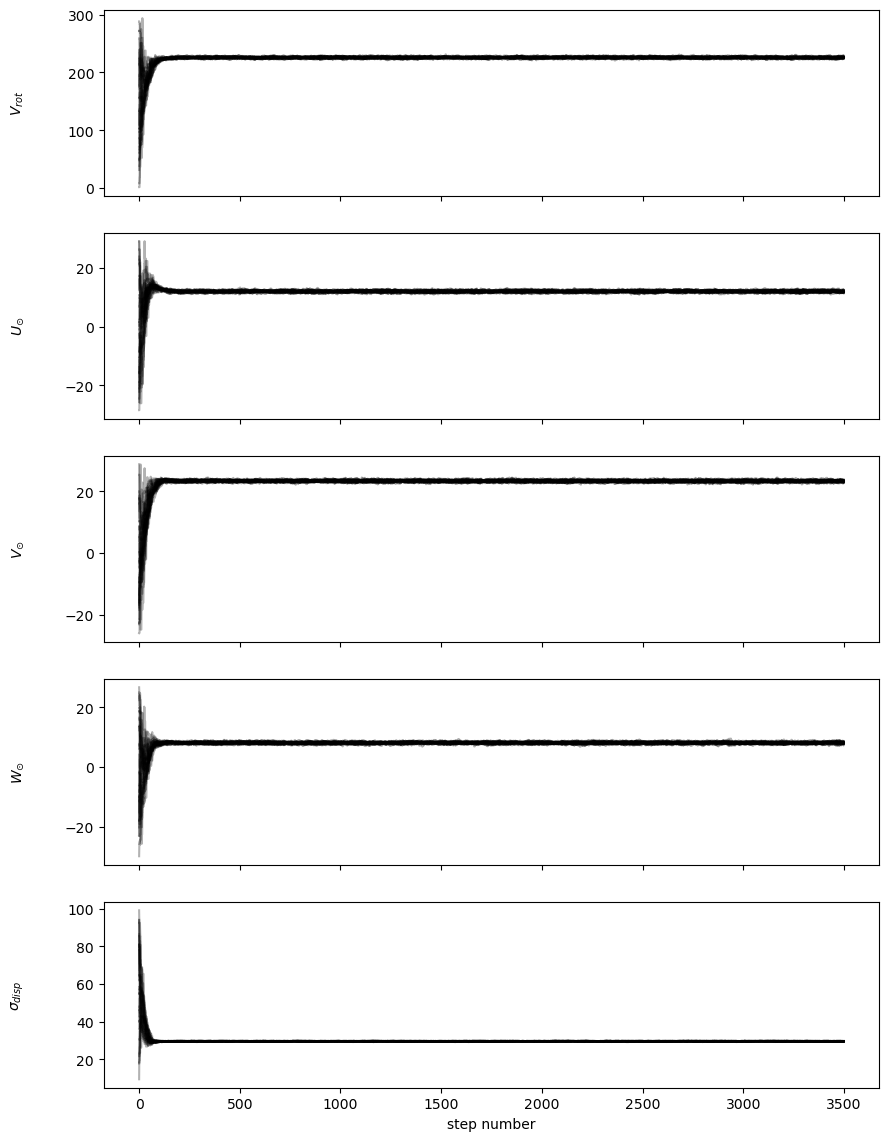

In [19]:
# Plotting the chains for each parameter

fig, axes = plt.subplots(5, figsize=(10, 14), sharex=True)
labels = [r"$V_{rot}$", r"$U_{\odot}$", r"$V_{\odot}$", r"$W_{\odot}$", r"$\sigma_{disp}$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

Autocorrelation time: 55.97
Flattened samples shape: (6912, 5)


Text(0.5, 0, 'step number')

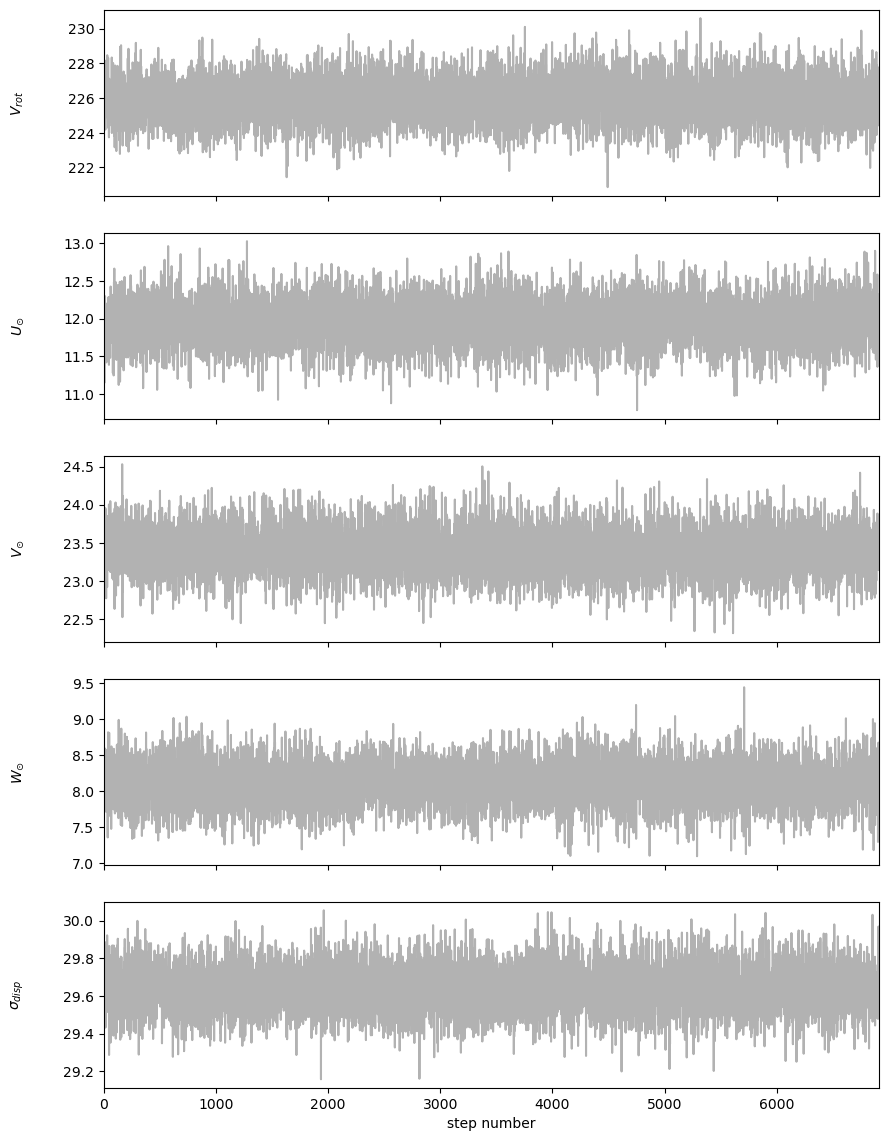

In [20]:
# Check autocorrelation time and convergence
tau = sampler.get_autocorr_time()
print(f"Autocorrelation time: {tau[0]:.2f}")

# Discarding burn-in samples...

flat_samples = sampler.get_chain(discard=250, thin=15, flat=True)
print(f"Flattened samples shape: {flat_samples.shape}")

# Plot flat samples
fig, axes = plt.subplots(5, figsize=(10, 14), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number")

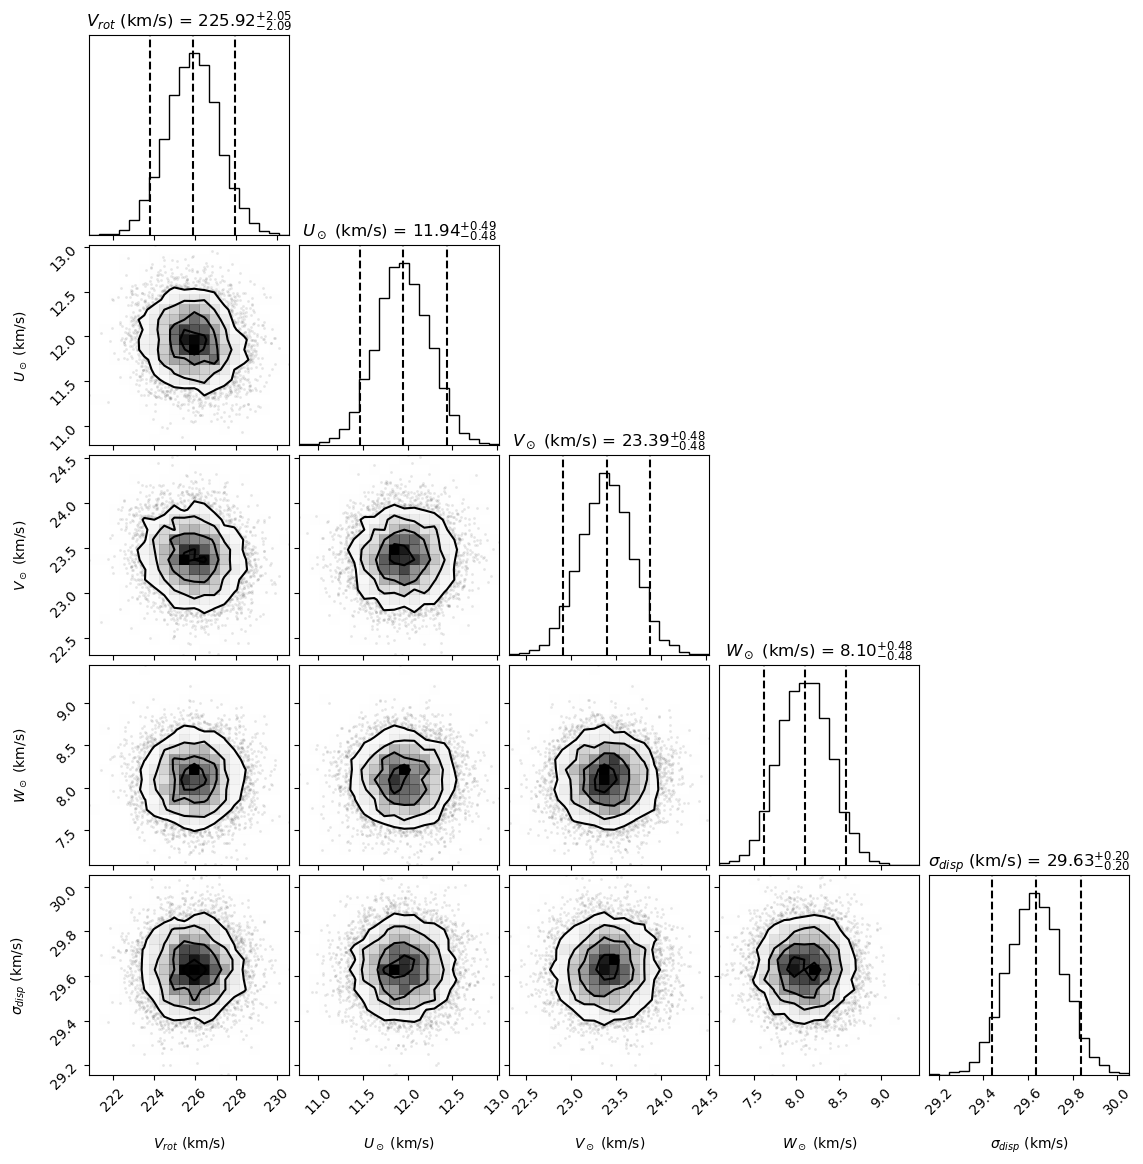

In [21]:
# Making corner plot

import corner 

fig = corner.corner(
    flat_samples, labels=(
        r"$V_{rot}$ (km/s)", 
        r"$U_\odot$ (km/s)", 
        r"$V_\odot$ (km/s)", 
        r"$W_\odot$ (km/s)",
        r"$\sigma_{disp}$ (km/s)"
    )
    , show_titles=True, title_kwargs={"fontsize": 12}, quantiles=[0.05, 0.5, 0.95]
)
plt.show()

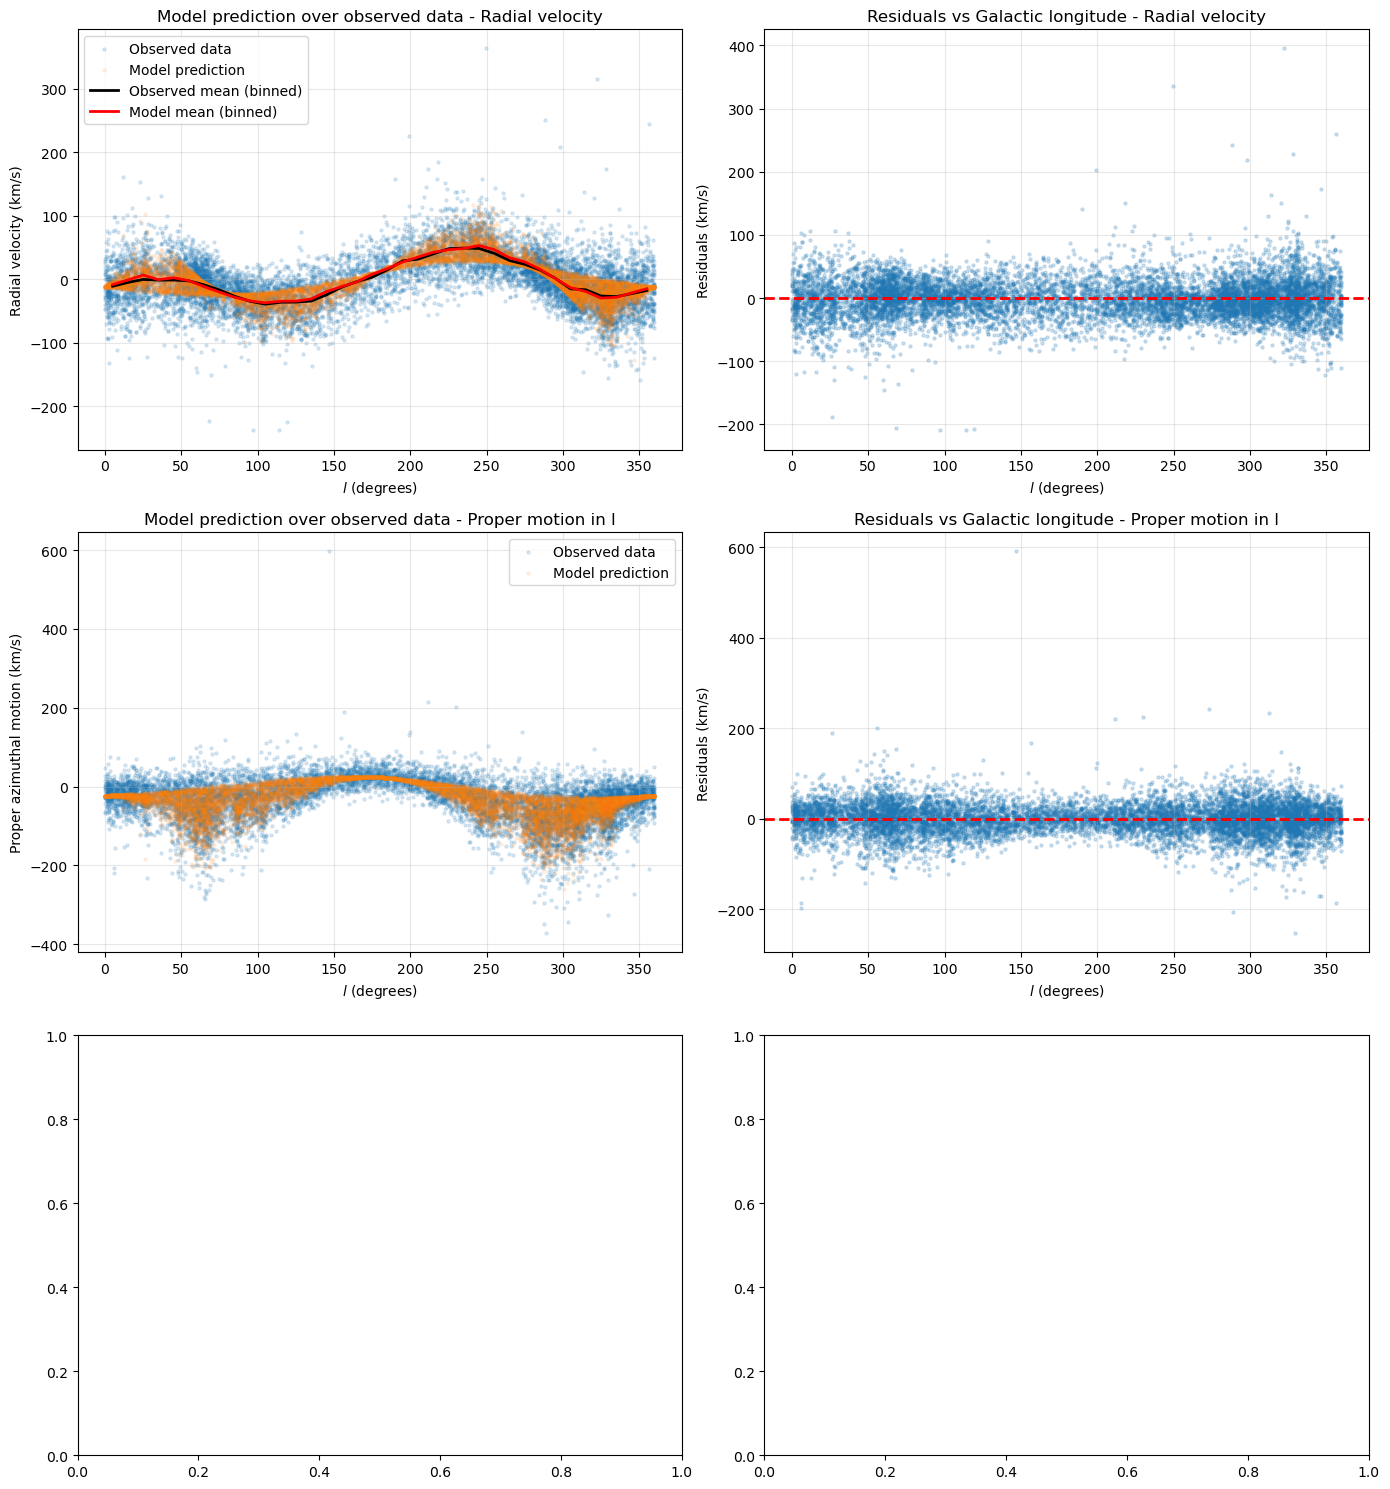

<Figure size 640x480 with 0 Axes>

In [ ]:
# Use posterior median parameters 
theta_hat = np.median(flat_samples, axis=0)
V_rot_hat, U_sun_hat, V_sun_hat, W_sun_hat, sigma_disp_hat = theta_hat

# Radial velocity for each star using its own distance
l_obs = np.asarray(data['l'].data)
d_obs = np.asarray(data['distance'].data)
b_obs = np.asarray(data['b'].data)

rv_obs = np.asarray(data['radial_velocity'].data)

# Predicted quantities using the model with the best-fit parameters
rv_pred = radial_velocity(V_rot_hat, l_obs, b_obs, d_obs, U_sun_hat, V_sun_hat, W_sun=W_sun_hat)
l_vel_pred = l_velocity(V_rot_hat, l_obs, b_obs, d_obs, U_sun_hat, V_sun_hat, W_sun_hat)
b_vel_pred = b_velocity(V_rot_hat, l_obs, b_obs, d_obs, U_sun_hat, V_sun_hat, W_sun_hat)


# Build binned trends vs Galactic longitude for a clearer overlay
bins = np.linspace(0, 360, 37)  # 10-degree bins
centers = 0.5 * (bins[:-1] + bins[1:])
obs_binned = np.full(len(centers), np.nan)
pred_binned = np.full(len(centers), np.nan)

for i in range(len(centers)):
    in_bin = (l_obs >= bins[i]) & (l_obs < bins[i + 1])
    if np.any(in_bin):
        obs_binned[i] = np.mean(rv_obs[in_bin])
        pred_binned[i] = np.mean(rv_pred[in_bin])

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Data + model overlay
ax = axes[0][0]
ax.scatter(l_obs, rv_obs, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, rv_pred, s=5, alpha=0.10, label='Model prediction')
ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Radial velocity (km/s)')
ax.set_title('Model prediction over observed data - Radial velocity')
ax.grid(alpha=0.3)
ax.legend()

# Residuals
ax = axes[0][1]
residuals = rv_obs - rv_pred
ax.scatter(l_obs, residuals, s=5, alpha=0.2)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Residuals (km/s)')
ax.set_title('Residuals vs Galactic longitude - Radial velocity')
ax.grid(alpha=0.3)

'''
# Data + model overlay
ax = axes[1][0]
ax.scatter(l_obs, l_vel, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, l_vel_pred, s=5, alpha=0.10, label='Model prediction')
#ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
#ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Proper azimuthal motion (km/s)')
ax.set_title('Model prediction over observed data - Proper motion in l')
ax.grid(alpha=0.3)
ax.legend()

# Residuals
ax = axes[1][1]
residuals = l_vel - l_vel_pred
ax.scatter(l_obs, residuals, s=5, alpha=0.2)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Residuals (km/s)')
ax.set_title('Residuals vs Galactic longitude - Proper motion in l')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Data + model overlay
ax = axes[2][0]
ax.scatter(l_obs, b_vel, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, b_vel_pred, s=5, alpha=0.10, label='Model prediction')
#ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
#ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_xlim(0, 360)
ax.set_ylim(-50, 50)
ax.set_ylabel('Proper polar motion (km/s)')
ax.set_title('Model prediction over observed data - Proper motion in b')
ax.grid(alpha=0.3)
ax.legend()

# Residuals
ax = axes[2][1]
residuals = b_vel - b_vel_pred
ax.scatter(l_obs, residuals, s=5, alpha=0.2)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Residuals (km/s)')
ax.set_title('Residuals vs Galactic longitude - Proper motion in b')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
'''